# Entrega 2 · Entrenamiento del modelo
### Predicción de renuncias de empleados (IBM HR Analytics)

M71V/M72V 02 · Implementación de Modelos de Aprendizaje Automático · UBA · **Giovanni Raffo**

La primera celda solo actúa en Google Colab: descarga el proyecto e instala lo necesario.

In [1]:
import sys, os
if "google.colab" in sys.modules:
    if not os.path.exists("/content/attrition-uba"):
        !git clone -q https://github.com/gioaqp/attrition-uba.git /content/attrition-uba
    %cd /content/attrition-uba/notebooks
    !pip install -q scikit-learn==1.9.1

## 1. Punto de partida

En la Entrega 1 quedaron los datos limpios, el grupo de examen apartado y la receta de preparación. Ahora se entrena **un solo modelo**, se ajusta con validación cruzada, se elige el punto de corte con criterio de negocio, se evalúa una única vez en el grupo de examen y se guarda listo para la API.

## 2. Los mismos datos, la misma separación

Se repiten las líneas de la Entrega 1 con la misma semilla: el grupo de examen es idéntico.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

df = pd.read_csv("../data/WA_Fn-UseC_-HR-Employee-Attrition.csv", encoding="utf-8-sig")
constantes = df.columns[df.nunique() == 1].tolist()
identificadores = df.columns[df.nunique() == len(df)].tolist()
df = df.drop(columns=constantes + identificadores + ["JobLevel"])

objetivo = "Attrition"
categoricas = df.drop(columns=objetivo).select_dtypes("object").columns.tolist()
numericas = df.drop(columns=objetivo).select_dtypes("number").columns.tolist()

X = df.drop(columns=objetivo)
y = (df[objetivo] == "Yes").astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print("Entrenamiento:", len(X_train), "empleados,", y_train.sum(), "renuncias")
print("Examen:", len(X_test), "empleados,", y_test.sum(), "renuncias")

Entrenamiento: 1176 empleados, 190 renuncias
Examen: 294 empleados, 47 renuncias


**Resultado:** 294 empleados y 47 renuncias en el examen, igual que en la Entrega 1.

## 3. El modelo: regresión logística

**Decisión:** un solo modelo, regresión logística. Da una probabilidad de renuncia por empleado y un peso por variable que Recursos Humanos puede leer: cuánto suma hacer horas extra, cuánto resta la antigüedad. Con 1.470 empleados, un modelo simple y regularizado generaliza mejor que uno complejo. `class_weight="balanced"` aplica los pesos de clase definidos en la Entrega 1.

La receta de preparación y el modelo van juntos en un solo pipeline: entran los datos crudos del empleado y sale la probabilidad.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

preparacion = ColumnTransformer([
    ("num", StandardScaler(), numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary", sparse_output=False), categoricas),
])
pipeline = Pipeline([
    ("preparacion", preparacion),
    ("modelo", LogisticRegression(class_weight="balanced", solver="liblinear", max_iter=1000)),
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preparacion', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

## 4. Validación cruzada, sin ajustar

Cinco rondas dentro del 80 % de entrenamiento: en cada una se entrena con cuatro partes y se valida con la quinta. El examen no se toca. La métrica principal es ROC-AUC: qué tan bien ordena el modelo a los empleados por riesgo (0,5 es azar, 1 es perfecto).

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate

validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas = ["roc_auc", "recall", "precision", "f1", "accuracy"]
res = cross_validate(pipeline, X_train, y_train, cv=validacion, scoring=metricas)
for m in metricas:
    print(m, round(res["test_" + m].mean(), 3))

roc_auc 0.829
recall 0.732
precision 0.369
f1 0.489
accuracy 0.752


**Lectura:** ROC-AUC 0,83 frente a 0,50 del baseline. Detecta el 73 % de las renuncias (recall); de cada tres empleados marcados, uno renuncia (precisión 0,37). La exactitud baja del 84 % al 75 % y no importa: ahora sí se detectan renuncias.

## 5. Ajuste de hiperparámetros

Se prueban 12 configuraciones: 6 niveles de regularización (`C`, el freno que evita que el modelo se aferre a los datos de entrenamiento) por 2 tipos de penalización (L1, que puede anular variables, y L2, que reparte el peso). Cada una se evalúa con la misma validación cruzada y se elige la de mayor ROC-AUC.

In [5]:
from sklearn.model_selection import GridSearchCV

grilla = {"modelo__C": [0.01, 0.03, 0.1, 0.3, 1, 3], "modelo__l1_ratio": [1, 0]}
busqueda = GridSearchCV(pipeline, grilla, cv=validacion, scoring="roc_auc")
busqueda.fit(X_train, y_train)
print("Mejor configuración:", busqueda.best_params_, "  ROC-AUC:", round(busqueda.best_score_, 3))

resultados = pd.DataFrame(busqueda.cv_results_)[["param_modelo__C", "param_modelo__l1_ratio", "mean_test_score", "std_test_score"]]
resultados.columns = ["C", "penalización", "ROC-AUC", "desvío"]
resultados["penalización"] = resultados["penalización"].map({1: "L1", 0: "L2"})
resultados.sort_values("ROC-AUC", ascending=False).head(5).round(3)

Mejor configuración: {'modelo__C': 0.3, 'modelo__l1_ratio': 0}   ROC-AUC: 0.831


,C,penalización,ROC-AUC,desvío
7,0.3,L2,0.831,0.029
5,0.1,L2,0.831,0.029
6,0.3,L1,0.829,0.027
9,1.0,L2,0.829,0.028
8,1.0,L1,0.828,0.027


**Lectura:** la mejor es C = 0,3 con L2, ROC-AUC 0,831. Las cinco primeras están a menos de tres milésimas: el modelo ya estaba bien regularizado y el ajuste cambia poco. **Decisión:** se usa la mejor configuración.

## 6. Punto de corte

El modelo da una probabilidad; hay que decidir desde qué valor se marca a un empleado como riesgo de renuncia. Perder a un empleado sin anticiparlo cuesta meses de reemplazo; una conversación de retención de más cuesta poco. **Regla de negocio:** detectar al menos 8 de cada 10 renuncias con la menor cantidad de falsas alarmas. El corte se elige con las predicciones de validación cruzada sobre el entrenamiento; el examen sigue sin tocarse.

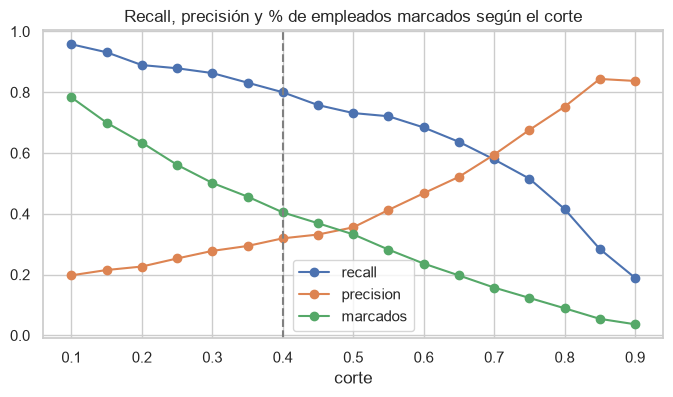

Corte elegido: 0.4


,corte,recall,precision,marcados
0,0.10,0.96,0.20,0.78
1,0.15,0.93,0.22,0.70
2,0.20,0.89,0.23,0.63
3,0.25,0.88,0.25,0.56
4,0.30,0.86,0.28,0.50
5,0.35,0.83,0.29,0.46
6,0.40,0.80,0.32,0.40
7,0.45,0.76,0.33,0.37
8,0.50,0.73,0.36,0.33
9,0.55,0.72,0.41,0.28


In [6]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import recall_score, precision_score
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

mejor = busqueda.best_estimator_
proba_cv = cross_val_predict(mejor, X_train, y_train, cv=validacion, method="predict_proba")[:, 1]

filas = []
for c in np.arange(0.1, 0.91, 0.05):
    pred = (proba_cv >= c).astype(int)
    filas.append([round(c, 2), recall_score(y_train, pred), precision_score(y_train, pred), pred.mean()])
cortes = pd.DataFrame(filas, columns=["corte", "recall", "precision", "marcados"])
corte = cortes[cortes["recall"] >= 0.8]["corte"].max()

cortes.plot(x="corte", y=["recall", "precision", "marcados"], marker="o", figsize=(8, 4), title="Recall, precisión y % de empleados marcados según el corte")
plt.axvline(corte, color="gray", linestyle="--")
plt.show()
print("Corte elegido:", corte)
cortes.round(2)

**Decisión:** corte 0,40, el más alto que detecta el 80 % de las renuncias. Se marca al 40 % de los empleados; de cada tres marcados, uno renuncia. Con el corte estándar de 0,50 se detectaría el 73 %. El corte queda fijado dentro del modelo.

## 7. Evaluación final en el grupo de examen

Se entrena la mejor configuración con todo el entrenamiento y se fija el corte dentro del modelo. Es la **primera y única vez** que se usa el grupo de examen: 294 empleados que el modelo nunca vio.

In [7]:
from sklearn.model_selection import FixedThresholdClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score

modelo_final = FixedThresholdClassifier(mejor, threshold=corte).fit(X_train, y_train)
baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)

examen = pd.DataFrame(index=["ROC-AUC", "Recall", "Precisión", "F1", "Exactitud"])
for nombre, m in [("Baseline", baseline), ("Modelo final", modelo_final)]:
    pred = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    examen[nombre] = [roc_auc_score(y_test, proba), recall_score(y_test, pred), precision_score(y_test, pred, zero_division=0), f1_score(y_test, pred), accuracy_score(y_test, pred)]
examen.round(3)

,Baseline,Modelo final
ROC-AUC,0.50,0.812
Recall,0.00,0.787
Precisión,0.00,0.336
F1,0.00,0.471
Exactitud,0.84,0.718


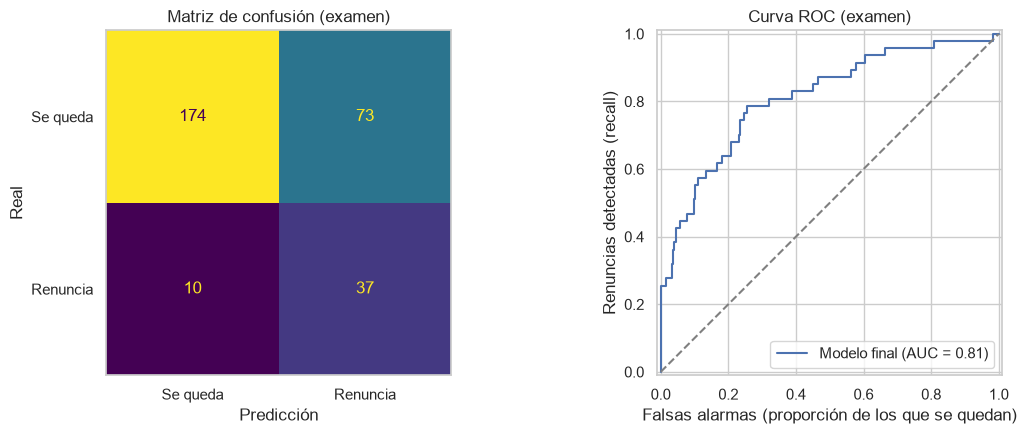

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay.from_estimator(modelo_final, X_test, y_test, display_labels=["Se queda", "Renuncia"], colorbar=False, ax=ejes[0])
ejes[0].set_title("Matriz de confusión (examen)")
ejes[0].set_xlabel("Predicción")
ejes[0].set_ylabel("Real")
ejes[0].grid(False)
RocCurveDisplay.from_estimator(modelo_final, X_test, y_test, name="Modelo final", ax=ejes[1])
ejes[1].plot([0, 1], [0, 1], "--", color="gray")
ejes[1].set_title("Curva ROC (examen)")
ejes[1].set_xlabel("Falsas alarmas (proporción de los que se quedan)")
ejes[1].set_ylabel("Renuncias detectadas (recall)")
plt.tight_layout()
plt.show()

**Lectura:** ROC-AUC 0,81 en el examen, en línea con el 0,83 de validación: no hay sobreajuste. Detecta 37 de las 47 renuncias (recall 0,79), con 73 falsas alarmas entre los 247 empleados que se quedan. El baseline no detecta ninguna.

## 8. Qué pesa más

Cada peso dice cuánto empuja esa variable hacia la renuncia (positivo) o hacia quedarse (negativo), con las demás fijas. Como las numéricas están escaladas, los pesos son comparables entre sí.

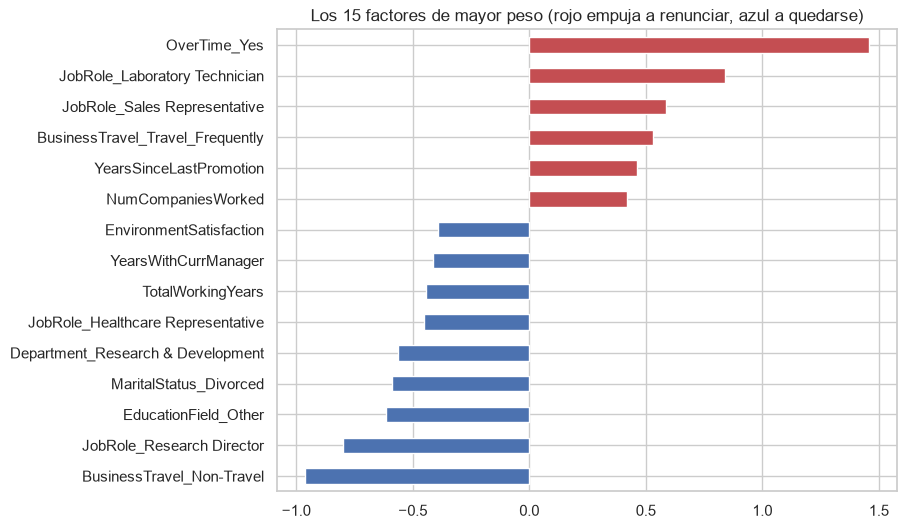

In [9]:
nombres = [n.split("__")[1] for n in modelo_final.estimator_.named_steps["preparacion"].get_feature_names_out()]
pesos = pd.Series(modelo_final.estimator_.named_steps["modelo"].coef_[0], index=nombres)
top = pesos[pesos.abs().nlargest(15).index].sort_values()

top.plot.barh(figsize=(8, 6), color=["#C44E52" if v > 0 else "#4C72B0" for v in top], title="Los 15 factores de mayor peso (rojo empuja a renunciar, azul a quedarse)")
plt.show()

**Lectura:** las horas extra son el factor de mayor peso, seguidas por los puestos de técnico de laboratorio y representante de ventas, los viajes frecuentes, los años sin ascenso y la cantidad de empresas previas. Protegen: no viajar, los años de carrera, el tiempo con el mismo jefe y la satisfacción con el entorno y con el trabajo.

Género y estado civil también pesan. Aportan señal, pero decidir retención por género o estado civil sería discriminatorio: en un uso real se auditaría el sesgo y se evaluaría excluirlas.

## 9. Guardar el modelo

Un solo archivo con la receta de preparación, el modelo y el punto de corte. Es el que carga la API en la Entrega 3: la preparación en producción es idéntica a la del entrenamiento por construcción. Las métricas quedan en `models/metricas.json`.

In [10]:
import joblib, json

os.makedirs("../models", exist_ok=True)
joblib.dump(modelo_final, "../models/modelo_attrition.pkl")

metricas_finales = {
    "modelo": "LogisticRegression",
    "configuracion": busqueda.best_params_,
    "corte": float(corte),
    "validacion_roc_auc": float(round(busqueda.best_score_, 3)),
    "examen": examen["Modelo final"].round(3).to_dict(),
}
with open("../models/metricas.json", "w", encoding="utf-8") as f:
    json.dump(metricas_finales, f, indent=2, ensure_ascii=False)
print("Guardado:", os.path.getsize("../models/modelo_attrition.pkl") // 1024, "KB")
metricas_finales

Guardado: 13 KB


{'modelo': 'LogisticRegression',
 'configuracion': {'modelo__C': 0.3, 'modelo__l1_ratio': 0},
 'corte': 0.4,
 'validacion_roc_auc': 0.831,
 'examen': {'ROC-AUC': 0.812,
  'Recall': 0.787,
  'Precisión': 0.336,
  'F1': 0.471,
  'Exactitud': 0.718}}

## 10. Prueba de recarga

Se carga el archivo como lo hará la API y se le pasa, con sus datos crudos y sin ningún paso manual, un empleado del examen que efectivamente renunció.

In [11]:
cargado = joblib.load("../models/modelo_attrition.pkl")
empleado = X_test[y_test == 1].iloc[[0]]
display(empleado.T)
print("Probabilidad de renuncia:", round(cargado.predict_proba(empleado)[0, 1], 2))
print("Predicción:", "Renuncia" if cargado.predict(empleado)[0] == 1 else "Se queda")

,69
Age,36
BusinessTravel,Travel_Rarely
DailyRate,318
Department,Research & Development
DistanceFromHome,9
Education,3
EducationField,Medical
EnvironmentSatisfaction,4
Gender,Male
HourlyRate,79


Probabilidad de renuncia: 0.66
Predicción: Renuncia


**Lectura:** el archivo recargado recibe al empleado tal como está en la tabla original y devuelve probabilidad 0,66, por encima del corte de 0,40: lo marca como riesgo, y efectivamente renunció. Hacía horas extra y ganaba poco. Si esto funciona acá, funciona en la API.

## 11. Cierre

| Punto de la consigna | Qué se hizo |
|---|---|
| Un solo modelo justificado | Regresión logística con pesos de clase |
| Entrenar usando el pipeline | Receta de preparación y modelo en un solo objeto |
| Tuning con validación | 12 configuraciones, validación cruzada de 5 partes, elegida por ROC-AUC |
| Punto de corte | 0,40 por regla de negocio: detectar 8 de cada 10 renuncias |
| Evaluación final en test | Una sola vez: ROC-AUC 0,81, recall 0,79 |
| Guardar modelo + pipeline | `models/modelo_attrition.pkl` y `models/metricas.json` |

**Sigue:** Entrega 3, la API.